In [1]:
#1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv('/content/Student Social Media And Mental Health Impact.csv')

In [4]:
df

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [6]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [7]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [8]:
df.duplicated().sum()


np.int64(2)

## EDA

In [9]:
# 4.1

# FOCUS


<Axes: >

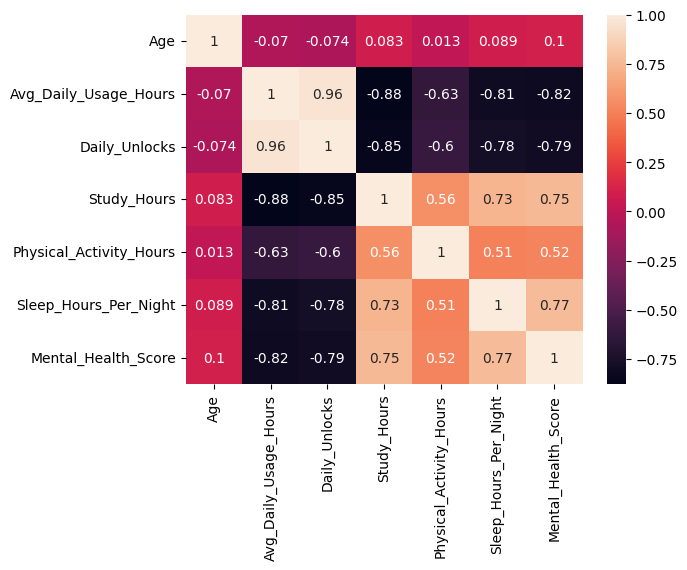

In [10]:
from numpy._core import numeric
#find corealtion of numeric and target
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [11]:
numer=df.select_dtypes(include=['int64','float64'])

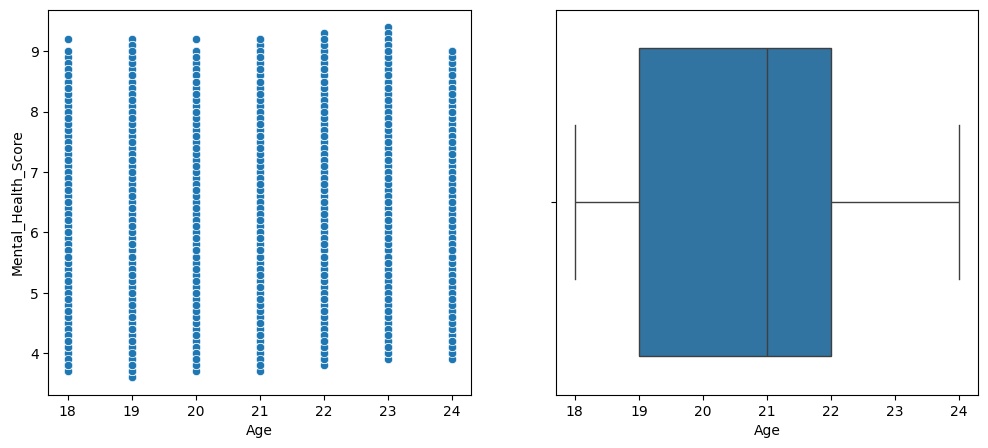

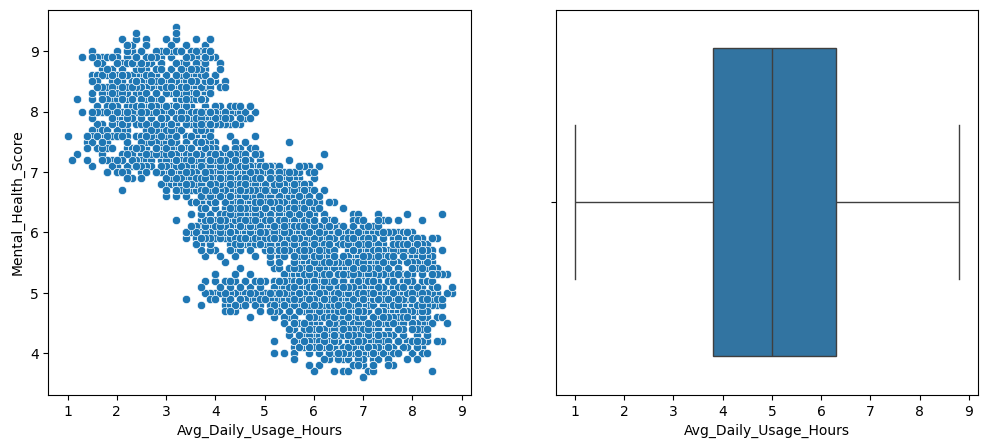

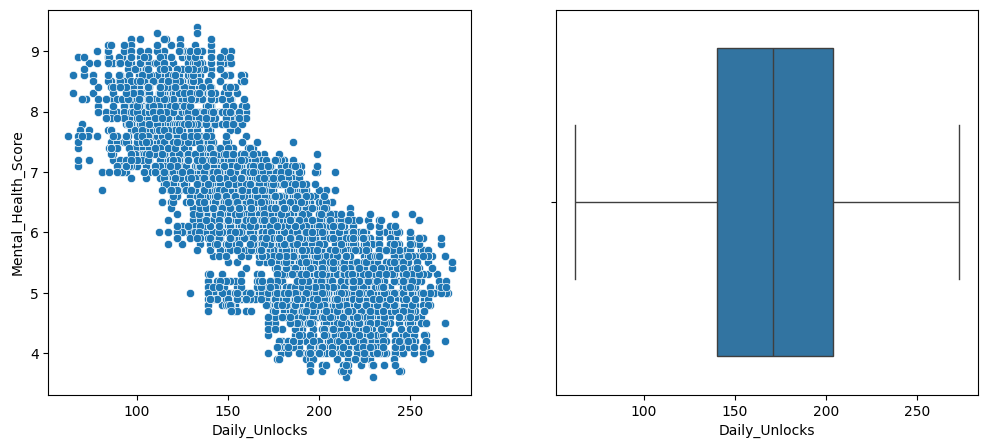

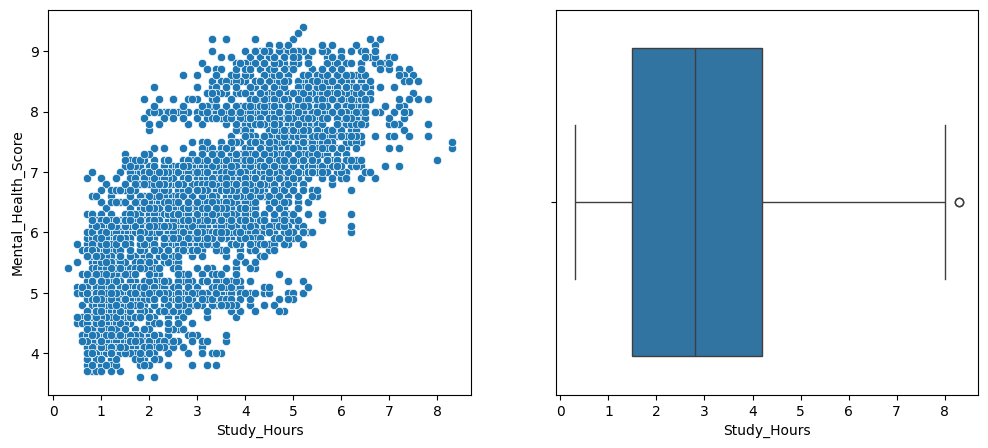

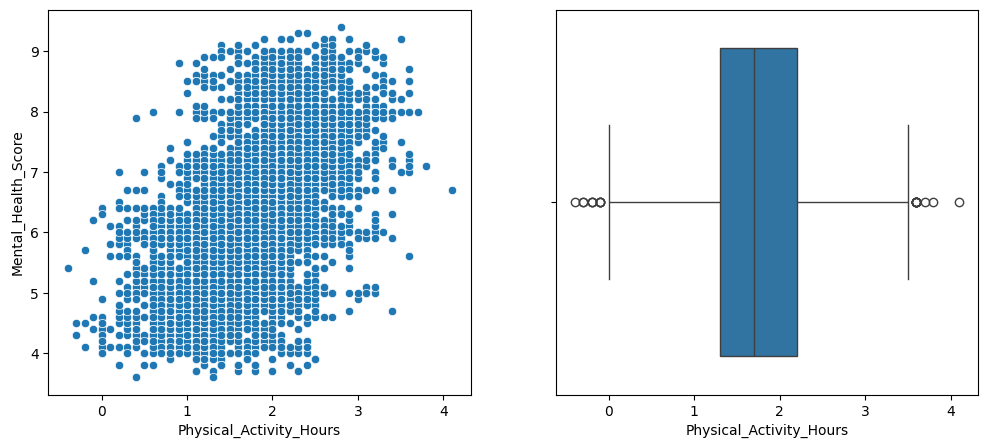

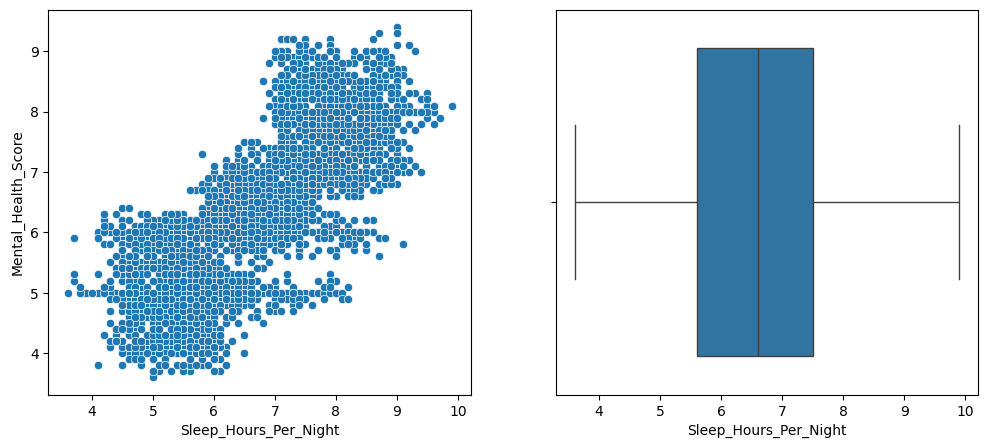

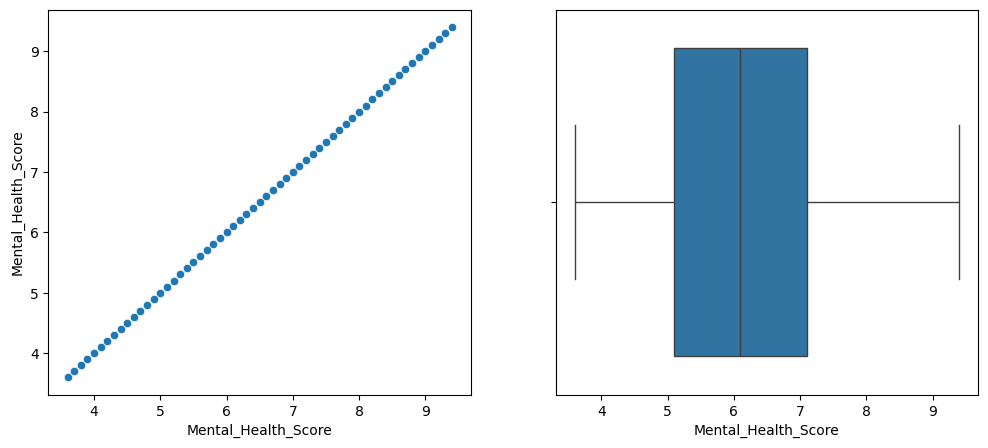

In [12]:
for i in numer:
  plt.figure(figsize=(12,5))
  plt.subplot(1,2,1)
  sns.scatterplot(x=df[i],y=df['Mental_Health_Score'])
  plt.subplot(1,2,2)
  sns.boxplot(x=df[i])

BOXPLOT


In [13]:
strin=df.select_dtypes(include=['object'])

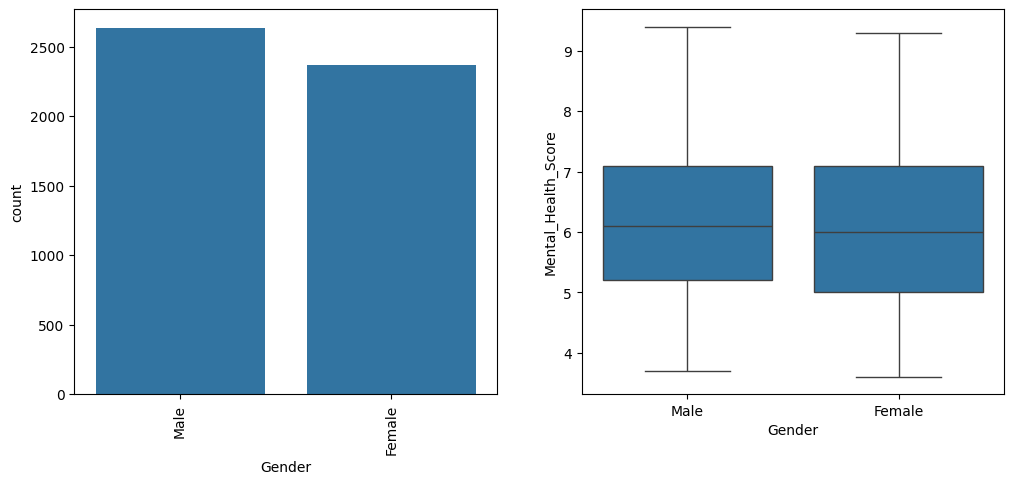

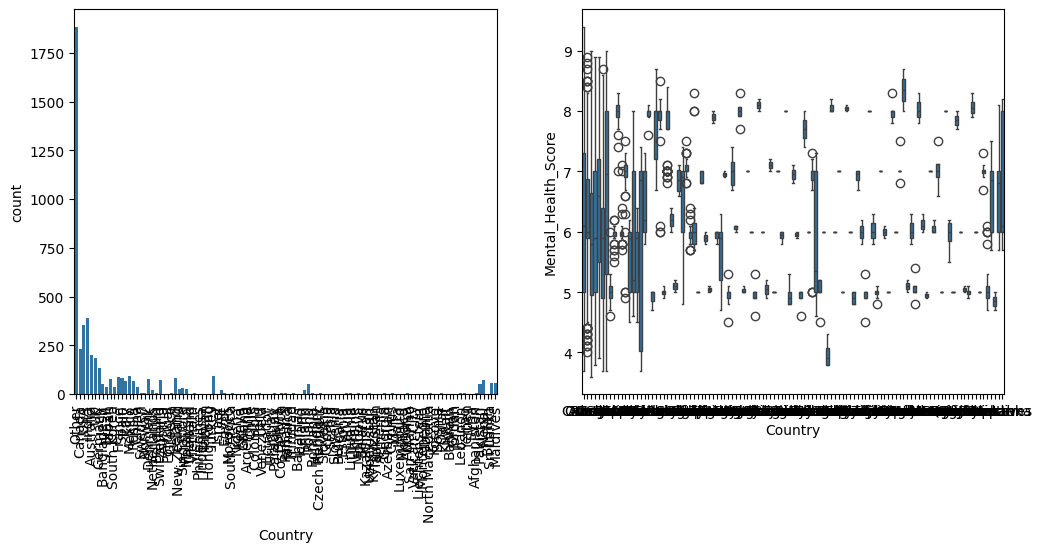

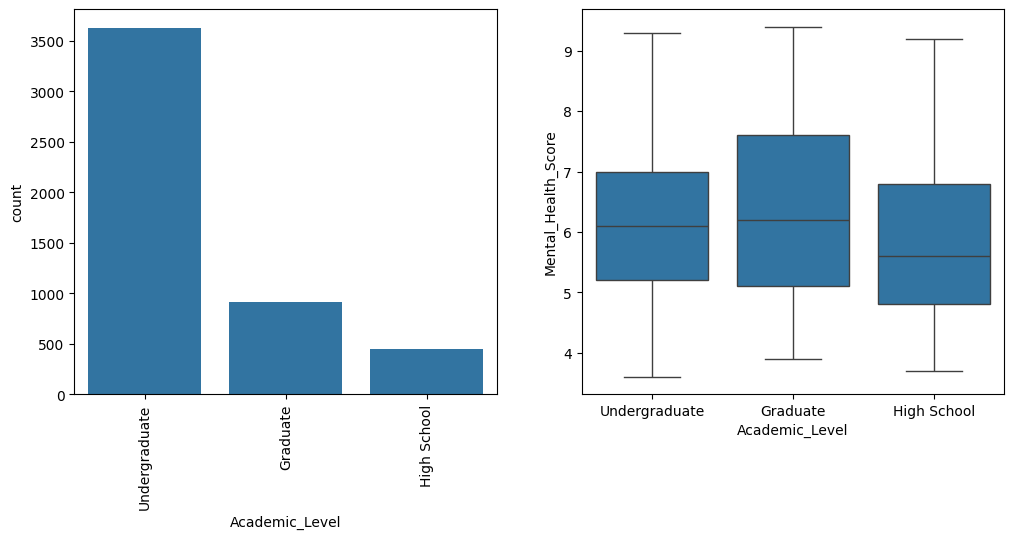

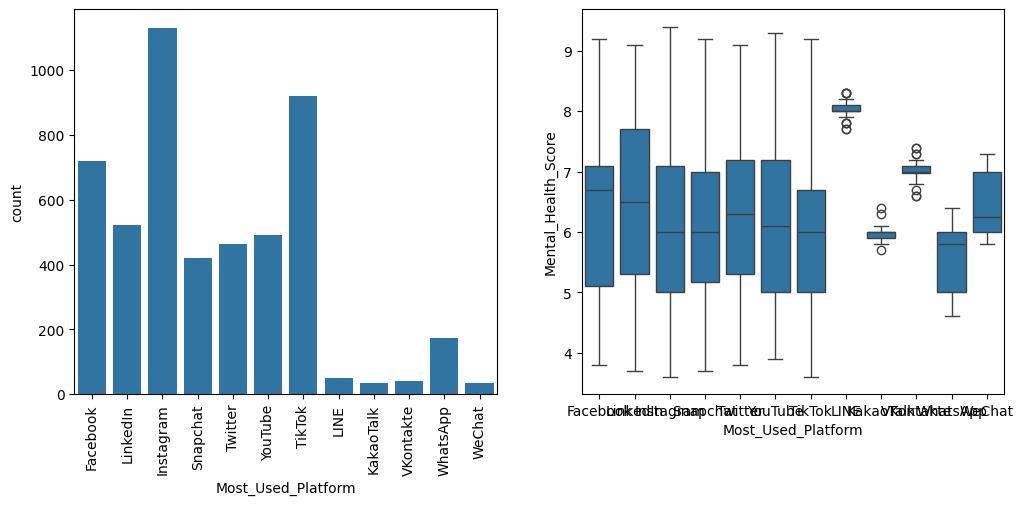

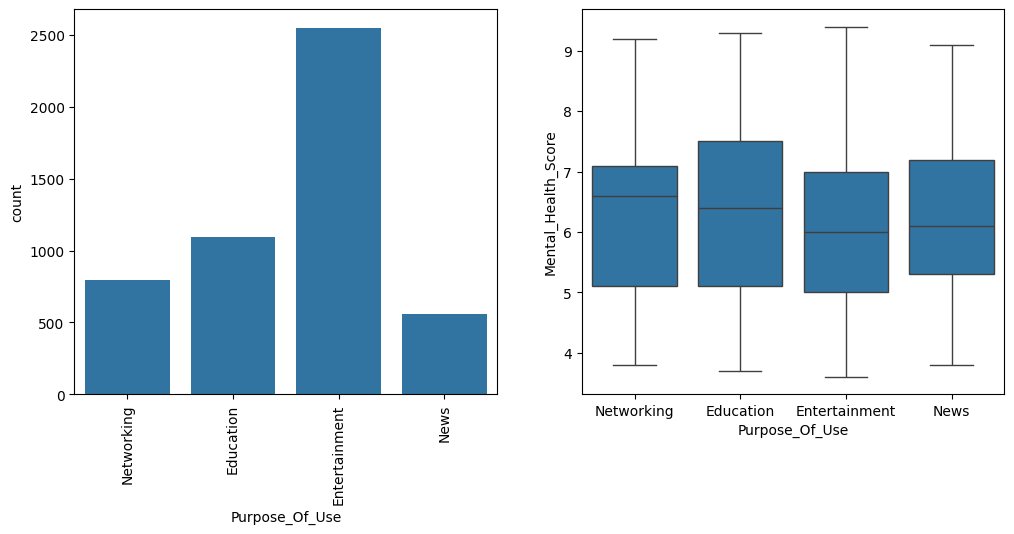

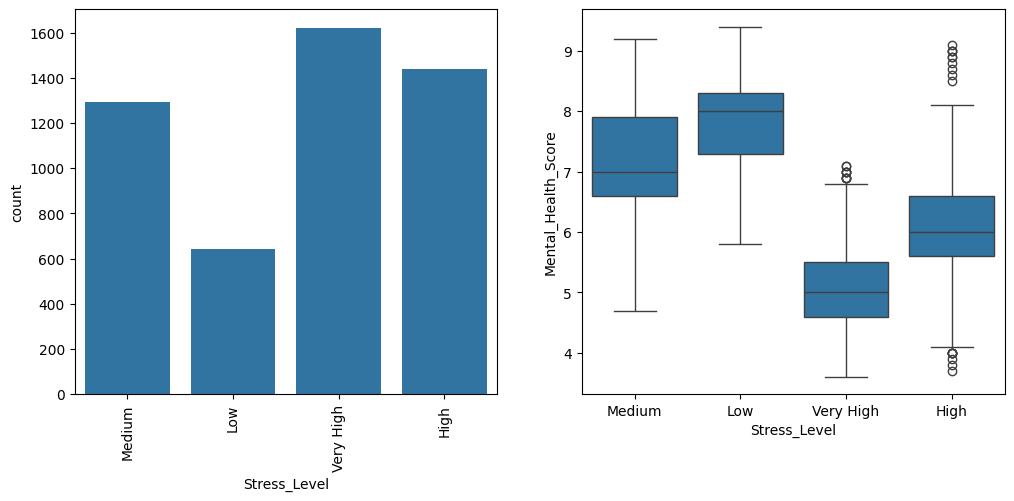

In [14]:
for i in strin:
  plt.figure(figsize=(12,5))
  plt.subplot(1,2,1)
  sns.countplot(x=df[i])
  plt.xticks(rotation=90)
  plt.subplot(1,2,2)
  sns.boxplot(x=df[i],y=df['Mental_Health_Score'])

# OUTLIER DETECTION

## FOCUS

In [15]:
Q1=numer.quantile(0.25)
Q3=numer.quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-(1.5)*IQR
upper_bound=Q3+(1.5)*IQR

outliers=(numer<lower_bound) | (numer>upper_bound)

print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


# DATA CLEANING

In [16]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [17]:
#1 DROP Duplicates
df=df.drop_duplicates()

#2.Converting negative or unrealistic value to realistic values gets to 0 by using clip function
# here in df we are getting -4.00000 which is unrealistic

df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

/tmp/ipykernel_2176/613735673.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)


In [18]:
df.shape

(4998, 13)

# Skewness




### What skewness is: a measure of how lopsided a numeric column's distribution is. A value near 0 means roughly symmetric (bell-shaped); a large positive or negative value means the data leans heavily to one side, with a long tail.

### Why it matters: models like Linear Regression assume features are roughly well-behaved. A heavily skewed column (think: a long tail of extreme values) can quietly drag the model's predictions in that direction. Tree-based models like Random Forest don't care about skew — but since we're also training a Linear Regression baseline, it's worth fixing.

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

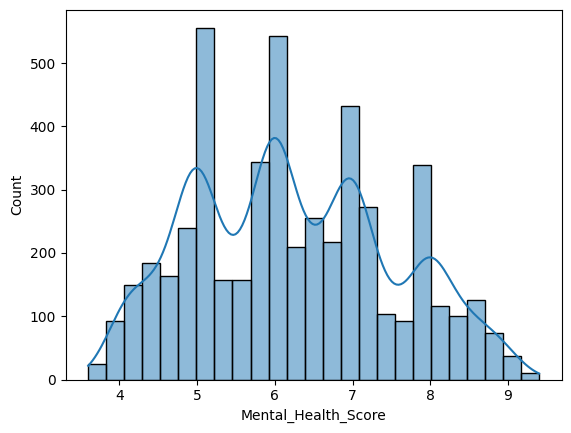

In [19]:
sns.histplot(x=df['Mental_Health_Score'],kde=True)

In [20]:
numer.skew()

,0
Age,0.155325
Avg_Daily_Usage_Hours,0.005606
Daily_Unlocks,0.002351
Study_Hours,0.435819
Physical_Activity_Hours,0.039971
Sleep_Hours_Per_Night,0.124050
Mental_Health_Score,0.206567


In [21]:
# if data is centralized then skew= 0
# if values near 0 is ok
# if negative is left skewed
# if positive right skewed

In [22]:
# To fix this we use Log transformation

# Feature Engineering
### One meaningful engineered feature here: grouping Country.

### Country has 111 unique values in this dataset — one-hot encoding that directly would add 110+ mostly-empty columns, which hurts the model far more than it helps (this is called high cardinality).
### Dropping Country entirely throws away real signal — a student's country genuinely correlates with things like internet access, culture, and sleep norms.
The fix: keep the top 10 most frequent countries as their own category, and bucket everything else into "Other". We keep the signal that matters and lose the noise that doesn't.

# VERY NEW LEARN IT

In [23]:
top_countries=df['Country'].value_counts().index[:10].tolist()

In [24]:
def group_countries(Country):
  if Country in top_countries:
    return Country
  else:
    return 'Other'

In [25]:
df['Grouped']=df['Country'].apply(group_countries)

/tmp/ipykernel_2176/839890626.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Grouped']=df['Country'].apply(group_countries)


In [26]:
df['Grouped'].value_counts()

,count
Grouped,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


### Result: we went from 111 raw categories down to 11 manageable ones (10 countries + "Other"). This is exactly the kind of decision that separates a project that "just ran pd.get_dummies()" from one that actually thought about the data.

### Encoding Strategy
Before we jump into code, let's decide how each categorical column should be encoded — this decision matters more than the code itself.

### Stress_Level → Ordinal Encoding. Its categories have a real, meaningful order: Low < Medium < High < Very High. We already saw in EDA (section 4.3) that the score drops step by step as stress increases — encoding it as 0, 1, 2, 3 preserves that order for the model.
### Gender, Academic_Level, Most_Used_Platform, Purpose_Of_Use, Country_Grouped → One-Hot Encoding. These categories have no natural order — "Instagram" isn't "greater than" "LinkedIn". One-hot encoding creates a separate 0/1 column per category so the model doesn't accidentally assume a false ranking.
### We'll implement both of these inside a single ColumnTransformer in the next step, rather than doing it manually column by column — that keeps preprocessing consistent and reusable.

## 9. Train-Test Split
### Why we split: we need data the model has never seen to honestly check how well it generalizes. If we evaluate on the same data we trained on, the model can just "memorize" the answers and look artificially good.

### ommon ratios: 80/20 or 70/30 are both standard. We'll use an 80/20 split here — with 5,000 rows, that still leaves 1,000 rows for a solid, reliable test.

### We split before fitting any preprocessing — this is the single most common beginner mistake (called data leakage), and we'll avoid it by fitting everything only on the training set.

In [27]:
from sklearn.model_selection import train_test_split

skwewd_col         = ['Study_Hours']  # Log transformation
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours",
                      "Sleep_Hours_Per_Night"]
ordinal_col        = ['Stress_Level']
normal_col         = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped"]


feature_col = skwewd_col + other_numeric_cols + ordinal_col + normal_col
X = df[feature_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [28]:
# 1:33:30

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer

In [30]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

In [31]:

#--------------------------------------------------
skew_pipeline = Pipeline([
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())

])

numeric_pipeline = Pipeline([
    ('scale', StandardScaler())
])

Ordinal_pipeline=Pipeline([
    ('ordinal',OrdinalEncoder(categories=['Low','Medium','High','Very High']))
])

one_hot_pipeline=Pipeline([
    ('Onehot',OneHotEncoder(handle_unknown='ignore'))
])

#--------------------------------------------------

In [32]:
Preprocess=ColumnTransformer(transformers=[
  ('SKEWED_DATA',skew_pipeline,skwewd_col),
  ("NUMERIC_DATA",numeric_pipeline,other_numeric_cols),
  ('ORDINAL_DATA',Ordinal_pipeline,ordinal_col),
  ('ONE_HOT_DATA',one_hot_pipeline,normal_col)
])

In [33]:
skew_pipeline = Pipeline([
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

numeric_pipeline = Pipeline([
    ('scale', StandardScaler())
])

ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(
        categories=[['Low', 'Medium', 'High', 'Very High']]
    ))
])

one_hot_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# --------------------------------------------------

Preprocess = ColumnTransformer([
    ('SKEWED_DATA', skew_pipeline, skwewd_col),
    ('NUMERIC_DATA', numeric_pipeline, other_numeric_cols),
    ('ORDINAL_DATA', ordinal_pipeline, ordinal_col),
    ('ONE_HOT_DATA', one_hot_pipeline, normal_col)
])

In [34]:
Preprocess

ColumnTransformer(transformers=[('SKEWED_DATA',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['Study_Hours']),
                                ('NUMERIC_DATA',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('ORDINAL_DATA',
                                 Pipeline(steps=[('ordinal',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('ONE_HOT_DATA',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Academic_Level',
                                  'Most_Used_Platform', 'Purpose_Of_Use',
                                  'Grouped'])])

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

In [36]:
models = {

    "LinearRegression": {
        "pipeline": Pipeline([
            ("pre", Preprocess),
            ("model", LinearRegression())
        ]),
        "param": {}
    },

    # ---------------------------------------------------------

    "KNN": {
        "pipeline": Pipeline([
            ("pre", Preprocess),
            ("model", KNeighborsRegressor())
        ]),
        "param": {
            "model__n_neighbors": [3, 5, 7],
            "model__metric": ["euclidean", "manhattan"],
            "model__weights": ["uniform", "distance"]
        }
    },

    # ---------------------------------------------------------

    "RandomForest": {
        "pipeline": Pipeline([
            ("pre", Preprocess),
            ("model", RandomForestRegressor())
        ]),
        "param": {
            "model__n_estimators": [50, 100],
            "model__max_depth": [5, 7, 15],
            "model__min_samples_split": [5, 7]
        }
    }
}

In [37]:
result=[]
best_models={}
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [38]:
for name,config in models.items():
  grid=RandomizedSearchCV(
      estimator=config['pipeline'],
      param_distributions=config['param'],
      cv=5,
      scoring='r2',
      n_jobs=-1
  )
  grid.fit(X_train,y_train)

  best_models[name]=grid.best_estimator_
  result.append({
      "Model":name,
      "BESTSCORE":grid.best_score_
  })

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [39]:
result_dff=pd.DataFrame(result)

In [40]:
result_dff

,Model,BESTSCORE
0,LinearRegression,0.717801
1,KNN,0.875689
2,RandomForest,0.841650


In [41]:
result_dff=result_dff.sort_values(by='BESTSCORE',ascending=False)

In [42]:
result_dff

,Model,BESTSCORE
1,KNN,0.875689
2,RandomForest,0.841650
0,LinearRegression,0.717801


In [43]:
best=result_dff.iloc[0].Model

In [44]:
best

'KNN'

In [45]:
bestt=best_models[best]

In [46]:
bestt.steps

[('pre',
  ColumnTransformer(transformers=[('SKEWED_DATA',
                                   Pipeline(steps=[('log_transform',
                                                    FunctionTransformer(func=<ufunc 'log1p'>)),
                                                   ('scale', StandardScaler())]),
                                   ['Study_Hours']),
                                  ('NUMERIC_DATA',
                                   Pipeline(steps=[('scale', StandardScaler())]),
                                   ['Age', 'Avg_Daily_Usage_Hours',
                                    'Daily_Unlocks', 'Physical_Activity_Hours',
                                    'Sleep_Hours_Per_Night']),
                                  ('ORDINAL_DATA',
                                   Pipeline(steps=[('ordinal',
                                                    OrdinalEncoder(categories=[['Low',
                                                                                'Medium',
      

In [47]:
y_pred=bestt.predict(X_test)
y_predT=bestt.predict(X_train)

In [48]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print(r2_score(y_test,y_pred))
print(r2_score(y_train,y_predT))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.9040211733492056
0.9999918615442751
0.28323527700340506
0.16857501470732886


In [49]:
best_models.items()

dict_items([('LinearRegression', Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('SKEWED_DATA',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('NUMERIC_DATA',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                   

In [50]:
for name,config in best_models.items():
  print(name)
  y_pred=config.predict(X_test)
  print(r2_score(y_test,y_pred))
  print(mean_absolute_error(y_test,y_pred))
  print(mean_squared_error(y_test,y_pred))


LinearRegression
0.7397944617433021
0.5361775634720181
0.45701905273487986
KNN
0.9040211733492056
0.28323527700340506
0.16857501470732886
RandomForest
0.869781859799607
0.3631912127081797
0.22871216147817533


In [51]:
import joblib

In [52]:
import joblib

joblib.dump(bestt, 'ML-1.pkl')

['ML-1.pkl']